<a href="https://colab.research.google.com/github/rezafarjad/Chest-X-Ray-/blob/main/chest_xray_classification_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI for Medicine Project - PyTorch Version

## Multi-Class Chest X-Ray Classification

This notebook rebuilds the chest X-ray classification project in PyTorch. It uses the COVID-19 Radiography Database and classifies images into four classes:

- COVID-19
- Lung Opacity
- Normal
- Viral Pneumonia

The workflow follows the same scientific structure as the TensorFlow/Keras version:

1. Audit image quality, masks, duplicates, and class distribution.
2. Remove corrupted files and exact duplicate images before splitting.
3. Create a stratified 80/20 development/test split.
4. Keep the hold-out test set untouched until the final evaluation.
5. Use stratified 5-fold cross-validation on the development set.
6. Compare exactly two models: a custom CNN baseline and pretrained MobileNetV2.
7. Select the best model from development-set cross-validation.
8. Evaluate the selected model once on the untouched hold-out test set.
9. Use Grad-CAM for model explainability.

This notebook is written as a clean PyTorch implementation, not a line-by-line TensorFlow conversion.


## 1. Environment Setup and Imports

The next cell installs lightweight notebook dependencies and imports all libraries used later. Google Colab already includes PyTorch and torchvision in most runtimes, so the install line avoids reinstalling them unless you choose to do so manually.


In [1]:
!pip -q install kagglehub scikit-learn seaborn tqdm

# Standard library imports
import copy
import hashlib
import os
import platform
import random
import sys
import time
from pathlib import Path

# Data and image imports
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageFile
from tqdm.auto import tqdm

# Scikit-learn imports
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

ImageFile.LOAD_TRUNCATED_IMAGES = False


## 2. Reproducibility and Configuration

The next cell fixes random seeds, selects GPU automatically, and stores all important experiment settings in one place.

Important Colab note: full 5-fold deep-learning cross-validation is not practical on CPU. This notebook now stops early if CUDA is not available, so you do not accidentally spend hours training on CPU.


In [2]:
SEED = 42

# Full 5-fold CNN + MobileNetV2 training should be run on GPU.
# Set this to False only for a tiny debugging run.
REQUIRE_GPU_FOR_FULL_TRAINING = True

# Deterministic CUDA can be much slower. Seeds are still fixed, but CuDNN
# benchmarking is enabled for practical Colab runtime.
REPRODUCIBLE_BUT_SLOW = False


def set_seed(seed=SEED):
    """Fix the main random seeds used by Python, NumPy, and PyTorch."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = REPRODUCIBLE_BUT_SLOW
    torch.backends.cudnn.benchmark = not REPRODUCIBLE_BUT_SLOW


def seed_worker(worker_id):
    """Give every DataLoader worker a deterministic seed."""

    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

if REQUIRE_GPU_FOR_FULL_TRAINING and DEVICE.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. In Google Colab, go to "
        "Runtime -> Change runtime type -> GPU, then restart and run again."
    )

CLASS_NAMES = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral Pneumonia",
]

DISPLAY_CLASS_NAMES = [
    "COVID-19",
    "Lung Opacity",
    "Normal",
    "Viral Pneumonia",
]

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: class_name
    for class_name, index in CLASS_TO_INDEX.items()
}

IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg")
IMAGE_SIZE = 224
NUM_CLASSES = len(CLASS_NAMES)

# Larger batches are faster on Colab GPU. If you get an out-of-memory error,
# reduce BATCH_SIZE to 32.
BATCH_SIZE = 64 if DEVICE.type == "cuda" else 16
NUM_WORKERS = min(4, os.cpu_count() or 2)
CV_FOLDS = 5

# CNN is only the baseline, so it is intentionally shorter.
# MobileNetV2 remains the main transfer-learning model.
CNN_EPOCHS = 3
MOBILENET_EPOCHS = 5
FINAL_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 2

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

OUTPUT_DIR = Path("pytorch_outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

environment_info = pd.DataFrame([
    {"item": "seed", "value": SEED},
    {"item": "device", "value": str(DEVICE)},
    {"item": "batch_size", "value": BATCH_SIZE},
    {"item": "num_workers", "value": NUM_WORKERS},
    {"item": "cnn_epochs", "value": CNN_EPOCHS},
    {"item": "mobilenet_epochs", "value": MOBILENET_EPOCHS},
    {"item": "python", "value": sys.version.split()[0]},
    {"item": "platform", "value": platform.platform()},
    {"item": "torch", "value": torch.__version__},
    {"item": "cuda_available", "value": torch.cuda.is_available()},
    {"item": "cuda_device_count", "value": torch.cuda.device_count()},
])

if torch.cuda.is_available():
    environment_info.loc[len(environment_info)] = {
        "item": "cuda_device_name",
        "value": torch.cuda.get_device_name(0),
    }

display(environment_info)


,item,value
0,seed,42
1,device,cuda
2,batch_size,64
3,num_workers,2
4,cnn_epochs,3
5,mobilenet_epochs,5
6,python,3.12.13
7,platform,Linux-6.6.122+-x86_64-with-glibc2.35
8,torch,2.11.0+cu128
9,cuda_available,True


## 3. Dataset Download

The next cell downloads the COVID-19 Radiography Database using KaggleHub. The dataset is not stored inside the Git repository; it is downloaded at runtime.


In [3]:
dataset_path = Path(
    kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
)


def find_dataset_root(path):
    """Find the folder that contains the four class directories."""

    candidate = path / "COVID-19_Radiography_Dataset"

    if candidate.exists():
        return candidate

    if all((path / class_name).exists() for class_name in CLASS_NAMES):
        return path

    raise FileNotFoundError(
        "Could not find COVID-19_Radiography_Dataset or the expected class folders."
    )


dataset_root = find_dataset_root(dataset_path)

print("Dataset path:", dataset_path)
print("Dataset root:", dataset_root)
print("Available folders:")

for item in sorted(dataset_root.iterdir()):
    if item.is_dir():
        print("-", item.name)


Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset path: /kaggle/input/covid19-radiography-database
Dataset root: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset
Available folders:
- COVID
- Lung_Opacity
- Normal
- Viral Pneumonia


## 4. Data Quality Audit

The next cells build a deterministic data-quality table. They check:

- image formats
- matching image and mask files
- missing masks
- extra masks without images
- corrupted images
- corrupted masks
- exact image hashes for duplicate detection

Masks are used here for data-quality checking. The classification models use the X-ray images as input.


In [4]:
def get_file_stem(filename):
    """Return the filename without its extension."""

    return Path(filename).stem


def calculate_file_hash(filepath, chunk_size=1024 * 1024):
    """Calculate a SHA-256 hash so exact duplicate image files can be found."""

    file_hash = hashlib.sha256()

    with open(filepath, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            file_hash.update(chunk)

    return file_hash.hexdigest()


def validate_image_file(filepath):
    """Open an image, verify it is readable, then reopen it to collect metadata."""

    with Image.open(filepath) as image:
        image.verify()

    with Image.open(filepath) as image:
        return {
            "width": image.width,
            "height": image.height,
            "mode": image.mode,
            "format": image.format,
        }


def collect_image_records(dataset_root, class_names):
    """Collect usable image records and record every data-quality issue."""

    records = []
    quality_issues = []
    mask_summary = []

    for class_name in class_names:
        class_dir = dataset_root / class_name
        image_dir = class_dir / "images"
        mask_dir = class_dir / "masks"

        image_files = sorted(
            filename
            for filename in os.listdir(image_dir)
            if filename.lower().endswith(IMAGE_EXTENSIONS)
        )

        if mask_dir.exists():
            mask_files = sorted(
                filename
                for filename in os.listdir(mask_dir)
                if filename.lower().endswith(IMAGE_EXTENSIONS)
            )
        else:
            mask_files = []
            quality_issues.append({
                "label": class_name,
                "filename": None,
                "issue": "mask_folder_missing",
            })

        image_stems = {
            get_file_stem(filename): filename
            for filename in image_files
        }

        mask_stems = {
            get_file_stem(filename): filename
            for filename in mask_files
        }

        missing_mask_stems = sorted(set(image_stems) - set(mask_stems))
        extra_mask_stems = sorted(set(mask_stems) - set(image_stems))

        mask_summary.append({
            "label": class_name,
            "images": len(image_files),
            "masks": len(mask_files),
            "missing_masks": len(missing_mask_stems),
            "extra_masks": len(extra_mask_stems),
        })

        for stem in missing_mask_stems:
            quality_issues.append({
                "label": class_name,
                "filename": image_stems[stem],
                "issue": "missing_mask",
            })

        for stem in extra_mask_stems:
            quality_issues.append({
                "label": class_name,
                "filename": mask_stems[stem],
                "issue": "extra_mask_without_image",
            })

        matched_stems = sorted(set(image_stems) & set(mask_stems))

        for stem in tqdm(matched_stems, desc=f"Checking {class_name}"):
            image_filename = image_stems[stem]
            mask_filename = mask_stems[stem]
            image_filepath = image_dir / image_filename
            mask_filepath = mask_dir / mask_filename

            try:
                image_metadata = validate_image_file(image_filepath)
            except (OSError, ValueError) as error:
                quality_issues.append({
                    "label": class_name,
                    "filename": image_filename,
                    "issue": "corrupted_image",
                    "error": str(error),
                })
                continue

            try:
                validate_image_file(mask_filepath)
            except (OSError, ValueError) as error:
                quality_issues.append({
                    "label": class_name,
                    "filename": mask_filename,
                    "issue": "corrupted_mask",
                    "error": str(error),
                })
                continue

            records.append({
                "filepath": str(image_filepath),
                "mask_filepath": str(mask_filepath),
                "filename": image_filename,
                "mask_filename": mask_filename,
                "label": class_name,
                "label_encoded": CLASS_TO_INDEX[class_name],
                "file_hash": calculate_file_hash(image_filepath),
                **image_metadata,
            })

    return (
        pd.DataFrame(records),
        pd.DataFrame(quality_issues),
        pd.DataFrame(mask_summary),
    )


image_records_df, quality_issues_df, mask_summary_df = collect_image_records(
    dataset_root,
    CLASS_NAMES,
)

print("Usable image records before duplicate removal:", len(image_records_df))
display(mask_summary_df)

if quality_issues_df.empty:
    print("No image/mask quality issues found.")
else:
    display(quality_issues_df["issue"].value_counts().rename("count").to_frame())
    display(quality_issues_df.head())


Checking COVID:   0%|          | 0/3616 [00:00<?, ?it/s]

Checking Lung_Opacity:   0%|          | 0/6012 [00:00<?, ?it/s]

Checking Normal:   0%|          | 0/10192 [00:00<?, ?it/s]

Checking Viral Pneumonia:   0%|          | 0/1345 [00:00<?, ?it/s]

Usable image records before duplicate removal: 21165


,label,images,masks,missing_masks,extra_masks
0,COVID,3616,3616,0,0
1,Lung_Opacity,6012,6012,0,0
2,Normal,10192,10192,0,0
3,Viral Pneumonia,1345,1345,0,0


No image/mask quality issues found.


In [5]:
format_summary_df = (
    image_records_df
    .groupby(["label", "format", "mode"])
    .size()
    .reset_index(name="count")
)

size_summary_df = (
    image_records_df
    .groupby("label")
    .agg(
        image_count=("filepath", "count"),
        median_width=("width", "median"),
        median_height=("height", "median"),
        min_width=("width", "min"),
        max_width=("width", "max"),
        min_height=("height", "min"),
        max_height=("height", "max"),
    )
    .reset_index()
)

display(format_summary_df)
display(size_summary_df)


,label,format,mode,count
0,COVID,PNG,L,3616
1,Lung_Opacity,PNG,L,6012
2,Normal,PNG,L,10192
3,Viral Pneumonia,PNG,L,1205
4,Viral Pneumonia,PNG,RGB,140


,label,image_count,median_width,median_height,min_width,max_width,min_height,max_height
0,COVID,3616,299.0,299.0,299,299,299,299
1,Lung_Opacity,6012,299.0,299.0,299,299,299,299
2,Normal,10192,299.0,299.0,299,299,299,299
3,Viral Pneumonia,1345,299.0,299.0,299,299,299,299


## 5. Duplicate Removal Before Splitting

Exact duplicate images are removed before any train/test split is created. This is important because duplicates across development and test sets would cause data leakage and inflate the final result.


In [6]:
duplicate_rows_df = (
    image_records_df
    .groupby("file_hash")
    .filter(lambda group: len(group) > 1)
    .sort_values(["file_hash", "label", "filename"])
)

exact_duplicate_groups = duplicate_rows_df["file_hash"].nunique()
duplicate_images_removed = len(image_records_df) - image_records_df["file_hash"].nunique()

cross_class_duplicate_groups = (
    duplicate_rows_df
    .groupby("file_hash")["label"]
    .nunique()
    .gt(1)
    .sum()
)

print("Exact duplicate groups:", exact_duplicate_groups)
print("Duplicate images removed:", duplicate_images_removed)
print("Duplicate groups spanning multiple classes:", cross_class_duplicate_groups)

if not duplicate_rows_df.empty:
    display(duplicate_rows_df[["label", "filename", "file_hash"]].head(10))

clean_df = (
    image_records_df
    .sort_values(["file_hash", "label", "filename"])
    .drop_duplicates("file_hash", keep="first")
    .reset_index(drop=True)
)

print("Clean dataset size:", len(clean_df))


Exact duplicate groups: 42
Duplicate images removed: 54
Duplicate groups spanning multiple classes: 0


,label,filename,file_hash
2011,COVID,COVID-2809.png,018f9fd3a0b986346ef6c18700e9091911415168bca59d...
2013,COVID,COVID-2810.png,018f9fd3a0b986346ef6c18700e9091911415168bca59d...
2014,COVID,COVID-2811.png,018f9fd3a0b986346ef6c18700e9091911415168bca59d...
2015,COVID,COVID-2812.png,018f9fd3a0b986346ef6c18700e9091911415168bca59d...
2016,COVID,COVID-2813.png,018f9fd3a0b986346ef6c18700e9091911415168bca59d...
1580,COVID,COVID-2420.png,17163011d42f04f3c7bc42c62f41dce27f0ef8c302a0c2...
1581,COVID,COVID-2421.png,17163011d42f04f3c7bc42c62f41dce27f0ef8c302a0c2...
2006,COVID,COVID-2804.png,1c936aadb8863220b08af52c4b133f387051950331bbb4...
2007,COVID,COVID-2805.png,1c936aadb8863220b08af52c4b133f387051950331bbb4...
20877,Viral Pneumonia,Viral Pneumonia-74.png,32fc384361eadb4841a5a51e1e3b5eaa33456f2a135e58...


Clean dataset size: 21111


## 6. Class Distribution

The next cell checks the class distribution after duplicate removal. The dataset is imbalanced, so class weights will be computed inside each training fold.


,label,count
0,COVID,3570
1,Lung_Opacity,6012
2,Normal,10191
3,Viral Pneumonia,1338


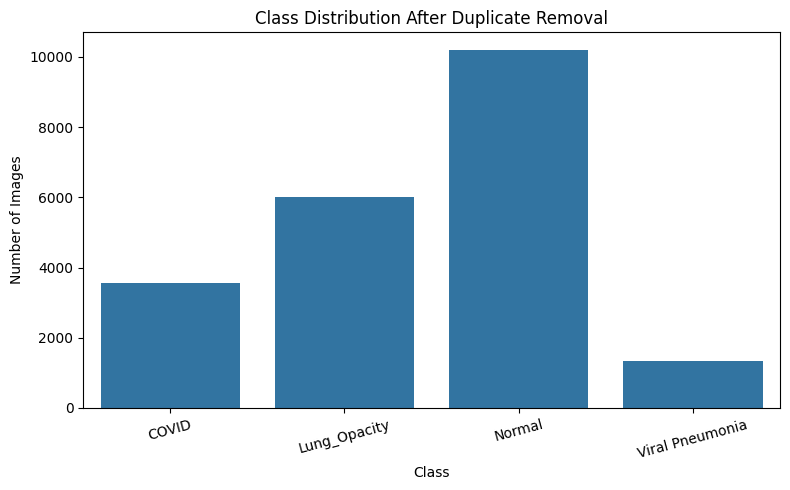

In [7]:
class_distribution_df = (
    clean_df["label"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename_axis("label")
    .reset_index(name="count")
)

display(class_distribution_df)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=class_distribution_df,
    x="label",
    y="count",
    order=CLASS_NAMES,
)
plt.title("Class Distribution After Duplicate Removal")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 7. Stratified Development/Test Split

The next cell creates a stratified 80/20 split:

- 80% development set for cross-validation and model selection
- 20% hold-out test set used only once after the best model is selected

The cell also checks that no exact image hash or file path appears in both sets.


In [8]:
development_df, test_df = train_test_split(
    clean_df,
    test_size=0.20,
    stratify=clean_df["label_encoded"],
    random_state=SEED,
)

development_df = development_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

development_hashes = set(development_df["file_hash"])
test_hashes = set(test_df["file_hash"])

development_paths = set(development_df["filepath"])
test_paths = set(test_df["filepath"])

hash_overlap = development_hashes.intersection(test_hashes)
path_overlap = development_paths.intersection(test_paths)

split_audit_df = pd.DataFrame([
    {
        "check": "development/test file path overlap",
        "value": len(path_overlap),
        "status": "pass" if len(path_overlap) == 0 else "fail",
    },
    {
        "check": "development/test exact image hash overlap",
        "value": len(hash_overlap),
        "status": "pass" if len(hash_overlap) == 0 else "fail",
    },
    {
        "check": "hold-out test fraction",
        "value": round(len(test_df) / len(clean_df), 4),
        "status": "pass",
    },
])

display(split_audit_df)

assert len(path_overlap) == 0, "Data leakage risk: file path appears in both development and test sets."
assert len(hash_overlap) == 0, "Data leakage risk: exact image hash appears in both development and test sets."

print("Development set:", len(development_df))
print("Hold-out test set:", len(test_df))


,check,value,status
0,development/test file path overlap,0.0,pass
1,development/test exact image hash overlap,0.0,pass
2,hold-out test fraction,0.2,pass


Development set: 16888
Hold-out test set: 4223


## 8. PyTorch Dataset and Image Transforms

The next cells define a reusable PyTorch `Dataset` and model-specific transforms.

The custom CNN uses simple normalization around 0.5. MobileNetV2 uses the ImageNet normalization expected by the pretrained torchvision backbone.


In [9]:
CNN_MEAN = [0.5, 0.5, 0.5]
CNN_STD = [0.5, 0.5, 0.5]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def get_transforms(model_name, train=True):
    """Create image preprocessing for the selected model."""

    if model_name == "CNN":
        mean = CNN_MEAN
        std = CNN_STD
    elif model_name == "MobileNetV2":
        mean = IMAGENET_MEAN
        std = IMAGENET_STD
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Keep augmentation light. Heavy PIL transforms like RandomRotation can
    # bottleneck PyTorch training on Colab because they run on CPU.
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])

    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])


class ChestXRayDataset(Dataset):
    """PyTorch Dataset that reads image paths and labels from a DataFrame."""

    def __init__(self, dataframe, transform=None, return_path=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.return_path = return_path

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        # Convert every image to RGB so both grayscale and RGB files have 3 channels.
        with Image.open(row["filepath"]) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["label_encoded"])

        if self.return_path:
            return image, label, row["filepath"]

        return image, label


def create_data_loader(dataframe, model_name, train=False, batch_size=BATCH_SIZE, return_path=False):
    """Create a DataLoader with the correct transforms for CNN or MobileNetV2."""

    dataset = ChestXRayDataset(
        dataframe=dataframe,
        transform=get_transforms(model_name, train=train),
        return_path=return_path,
    )

    generator = torch.Generator()
    generator.manual_seed(SEED)

    loader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": train,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "worker_init_fn": seed_worker,
        "generator": generator,
    }

    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2

    return DataLoader(**loader_kwargs)


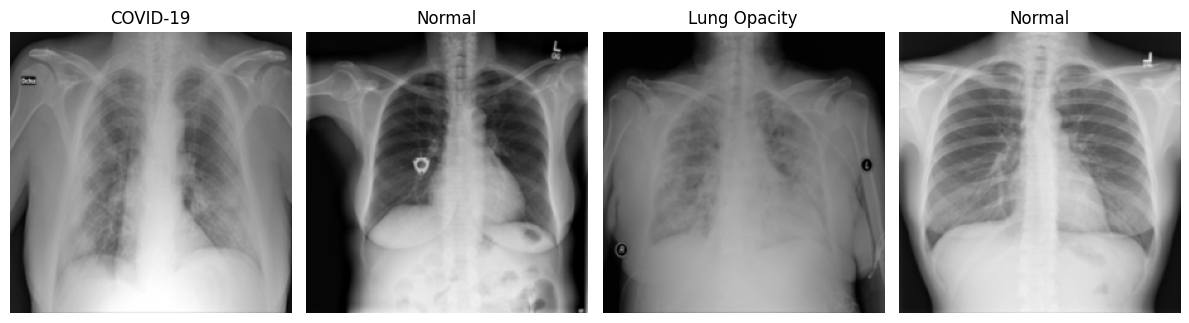

In [10]:
def denormalize_tensor(image_tensor, model_name):
    """Convert a normalized tensor back to displayable pixel values."""

    if model_name == "CNN":
        mean = torch.tensor(CNN_MEAN).view(3, 1, 1)
        std = torch.tensor(CNN_STD).view(3, 1, 1)
    else:
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = image_tensor.detach().cpu() * std + mean
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


sample_loader = create_data_loader(
    development_df.sample(n=min(8, len(development_df)), random_state=SEED),
    model_name="CNN",
    train=False,
    batch_size=8,
)

sample_images, sample_labels = next(iter(sample_loader))

plt.figure(figsize=(12, 4))
for index in range(min(4, len(sample_images))):
    plt.subplot(1, 4, index + 1)
    plt.imshow(denormalize_tensor(sample_images[index], "CNN"))
    plt.title(DISPLAY_CLASS_NAMES[int(sample_labels[index])])
    plt.axis("off")
plt.tight_layout()
plt.show()


## 9. Class Weights

The dataset is imbalanced. The next function computes class weights from the training labels only. During cross-validation, this is done separately for each training fold to avoid using validation information inside the loss function.


In [11]:
def compute_torch_class_weights(dataframe):
    """Return class weights as a PyTorch tensor for CrossEntropyLoss."""

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=dataframe["label_encoded"].values,
    )

    return torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)


example_class_weights = compute_torch_class_weights(development_df)

for class_index, weight in enumerate(example_class_weights.detach().cpu().numpy()):
    print(f"{DISPLAY_CLASS_NAMES[class_index]}: {weight:.4f}")


COVID-19: 1.4783
Lung Opacity: 0.8779
Normal: 0.5178
Viral Pneumonia: 3.9458


## 10. Model Definitions

The project intentionally uses exactly two models:

1. A custom CNN baseline trained from scratch.
2. A pretrained MobileNetV2 transfer-learning model from torchvision.

MobileNetV2 is frozen except for its classifier head. This keeps the transfer-learning setup efficient and comparable to the previous Keras project.


In [12]:
class CustomCNN(nn.Module):
    """Simple CNN baseline trained from scratch."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_mobilenetv2(num_classes=NUM_CLASSES):
    """Build a pretrained MobileNetV2 model and replace its classifier."""

    try:
        weights = models.MobileNet_V2_Weights.DEFAULT
        model = models.mobilenet_v2(weights=weights)
    except AttributeError:
        # Older torchvision versions use pretrained=True.
        model = models.mobilenet_v2(pretrained=True)

    for parameter in model.features.parameters():
        parameter.requires_grad = False

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes),
    )

    return model


def build_model(model_name):
    """Factory function for the two allowed project models."""

    if model_name == "CNN":
        return CustomCNN(num_classes=NUM_CLASSES)

    if model_name == "MobileNetV2":
        return build_mobilenetv2(num_classes=NUM_CLASSES)

    raise ValueError(f"Unsupported model name: {model_name}")


for model_name in ["CNN", "MobileNetV2"]:
    model = build_model(model_name)
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    total_parameters = sum(parameter.numel() for parameter in model.parameters())

    print(model_name)
    print("Total parameters:", f"{total_parameters:,}")
    print("Trainable parameters:", f"{trainable_parameters:,}")
    print()


CNN
Total parameters: 422,788
Trainable parameters: 422,788

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 132MB/s]

MobileNetV2
Total parameters: 2,228,996
Trainable parameters: 5,124



## 11. Training Utilities

The next cells define reusable training functions:

- one training epoch
- one validation epoch
- early stopping
- model checkpointing
- learning-rate scheduling

Beginner note: the model learns during `train_one_epoch`, while `evaluate_loss` checks validation performance without updating weights.


In [13]:
class EarlyStopping:
    """Stop training when validation loss stops improving."""

    def __init__(self, patience=EARLY_STOPPING_PATIENCE, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.should_stop = False

    def step(self, current_loss):
        if current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
            return True

        self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

        return False


def train_one_epoch(model, data_loader, criterion, optimizer, scaler=None):
    """Train the model for one epoch and return average loss and accuracy."""

    model.train()
    running_loss = 0.0
    all_true = []
    all_pred = []
    use_amp = DEVICE.type == "cuda"

    for images, labels in data_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)

        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(predictions.detach().cpu().numpy())

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_true, all_pred)

    return epoch_loss, epoch_accuracy


@torch.no_grad()
def evaluate_loss(model, data_loader, criterion):
    """Evaluate loss and accuracy without changing model weights."""

    model.eval()
    running_loss = 0.0
    all_true = []
    all_pred = []
    use_amp = DEVICE.type == "cuda"

    for images, labels in data_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)

        all_true.extend(labels.detach().cpu().numpy())
        all_pred.extend(predictions.detach().cpu().numpy())

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_true, all_pred)

    return epoch_loss, epoch_accuracy


In [14]:
def train_model(
    model,
    train_loader,
    val_loader,
    class_weights,
    checkpoint_path,
    epochs,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
):
    """Train a model with early stopping, checkpointing, and LR scheduling."""

    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = AdamW(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
    )

    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")
    history = []
    best_state_dict = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler=scaler,
        )

        val_loss, val_accuracy = evaluate_loss(
            model,
            val_loader,
            criterion,
        )

        scheduler.step(val_loss)

        improved = early_stopping.step(val_loss)

        if improved:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())

            torch.save(
                {
                    "model_state_dict": best_state_dict,
                    "val_loss": best_val_loss,
                    "epoch": epoch,
                },
                checkpoint_path,
            )

        epoch_record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "seconds": time.time() - start_time,
        }

        history.append(epoch_record)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_accuracy:.4f} | "
            f"val loss {val_loss:.4f} acc {val_accuracy:.4f} | "
            f"lr {optimizer.param_groups[0]['lr']:.2e}"
        )

        if early_stopping.should_stop:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state_dict)

    return model, pd.DataFrame(history)


## 12. Prediction and Metric Utilities

The next functions collect predictions and compute the evaluation metrics requested for the project:

- accuracy
- precision
- recall
- F1-score
- confusion matrix
- ROC curves
- macro AUC


In [15]:
@torch.no_grad()
def predict_model(model, data_loader):
    """Return true labels, predicted labels, class probabilities, and paths if available."""

    model.eval()
    model = model.to(DEVICE)

    y_true = []
    y_pred = []
    y_prob = []
    paths = []

    for batch in data_loader:
        if len(batch) == 3:
            images, labels, batch_paths = batch
            paths.extend(batch_paths)
        else:
            images, labels = batch

        images = images.to(DEVICE, non_blocking=True)

        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions.detach().cpu().numpy())
        y_prob.extend(probabilities.detach().cpu().numpy())

    result = {
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "y_prob": np.array(y_prob),
    }

    if paths:
        result["paths"] = paths

    return result


def compute_metrics(y_true, y_pred, y_prob):
    """Compute scalar metrics for model comparison."""

    y_true_binarized = label_binarize(
        y_true,
        classes=np.arange(NUM_CLASSES),
    )

    try:
        macro_auc = roc_auc_score(
            y_true_binarized,
            y_prob,
            average="macro",
        )
    except ValueError:
        macro_auc = np.nan

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_auc": macro_auc,
    }


def classification_report_dataframe(y_true, y_pred):
    """Create a readable classification report table."""

    return pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=DISPLAY_CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()


In [16]:
def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a confusion matrix with class names."""

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
    )

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=DISPLAY_CLASS_NAMES,
        yticklabels=DISPLAY_CLASS_NAMES,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_curves(y_true, y_prob, title):
    """Plot one-vs-rest ROC curves for all classes."""

    y_true_binarized = label_binarize(
        y_true,
        classes=np.arange(NUM_CLASSES),
    )

    plt.figure(figsize=(8, 6))

    auc_scores = {}

    for class_index, class_name in enumerate(DISPLAY_CLASS_NAMES):
        fpr, tpr, _ = roc_curve(
            y_true_binarized[:, class_index],
            y_prob[:, class_index],
        )

        class_auc = auc(fpr, tpr)
        auc_scores[class_name] = class_auc

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{class_name} (AUC = {class_auc:.4f})",
        )

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return auc_scores


## 13. Stratified 5-Fold Cross-Validation

The next function trains and validates one model across 5 stratified folds on the development set. The hold-out test set is not touched here.


In [17]:
def run_cross_validation(model_name, dataframe, epochs):
    """Run stratified 5-fold cross-validation for one model."""

    skf = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=SEED,
    )

    fold_results = []
    fold_histories = {}

    for fold, (train_index, val_index) in enumerate(
        skf.split(dataframe["filepath"], dataframe["label_encoded"]),
        start=1,
    ):
        print("\n" + "=" * 70)
        print(f"{model_name} | Fold {fold}/{CV_FOLDS}")
        print("=" * 70)

        train_fold_df = dataframe.iloc[train_index].reset_index(drop=True)
        val_fold_df = dataframe.iloc[val_index].reset_index(drop=True)

        train_loader = create_data_loader(
            train_fold_df,
            model_name=model_name,
            train=True,
        )

        val_loader = create_data_loader(
            val_fold_df,
            model_name=model_name,
            train=False,
        )

        class_weights = compute_torch_class_weights(train_fold_df)
        model = build_model(model_name)

        checkpoint_path = CHECKPOINT_DIR / f"{model_name}_fold_{fold}.pt"

        model, history_df = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            class_weights=class_weights,
            checkpoint_path=checkpoint_path,
            epochs=epochs,
        )

        prediction_result = predict_model(model, val_loader)
        metrics = compute_metrics(
            prediction_result["y_true"],
            prediction_result["y_pred"],
            prediction_result["y_prob"],
        )

        fold_record = {
            "model": model_name,
            "fold": fold,
            **metrics,
            "checkpoint": str(checkpoint_path),
        }

        fold_results.append(fold_record)
        fold_histories[fold] = history_df

        print("Fold metrics:")
        for metric_name, metric_value in metrics.items():
            print(f"{metric_name}: {metric_value:.4f}")

    return pd.DataFrame(fold_results), fold_histories


## 14. Train the Two Allowed Models

The next cell runs cross-validation for exactly two models:

- `CNN`
- `MobileNetV2`

This is the main development-set model comparison.


In [18]:
cnn_cv_results_df, cnn_cv_histories = run_cross_validation(
    model_name="CNN",
    dataframe=development_df,
    epochs=CNN_EPOCHS,
)

mobilenet_cv_results_df, mobilenet_cv_histories = run_cross_validation(
    model_name="MobileNetV2",
    dataframe=development_df,
    epochs=MOBILENET_EPOCHS,
)



CNN | Fold 1/5


/tmp/ipykernel_2387/607768529.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")
/tmp/ipykernel_2387/2409118514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2387/2409118514.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/3 | train loss 0.9436 acc 0.5804 | val loss 1.0552 acc 0.3961 | lr 1.00e-03


/tmp/ipykernel_2387/2409118514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2387/2409118514.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 02/3 | train loss 0.7272 acc 0.6668 | val loss 0.9285 acc 0.5234 | lr 1.00e-03


...

Epoch 03/5 | train loss 0.4648 acc 0.7965 | val loss 0.4431 acc 0.8037 | lr 1.00e-03


/tmp/ipykernel_2387/2409118514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2387/2409118514.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 04/5 | train loss 0.4326 acc 0.8045 | val loss 0.4256 acc 0.7972 | lr 1.00e-03


/tmp/ipykernel_2387/2409118514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2387/2409118514.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 05/5 | train loss 0.4182 acc 0.8087 | val loss 0.4123 acc 0.8057 | lr 1.00e-03
Fold metrics:
accuracy: 0.8028
macro_precision: 0.7717
macro_recall: 0.8474
macro_f1: 0.8008
weighted_f1: 0.8037
macro_auc: 0.9561


## 15. Model Comparison and Selection

The next cell compares cross-validation results and selects the best model using mean validation accuracy. The test set is still untouched at this point.


In [19]:
cv_results_df = pd.concat(
    [cnn_cv_results_df, mobilenet_cv_results_df],
    ignore_index=True,
)

model_comparison_df = (
    cv_results_df
    .groupby("model")
    .agg(
        mean_validation_accuracy=("accuracy", "mean"),
        std_validation_accuracy=("accuracy", "std"),
        mean_macro_auc=("macro_auc", "mean"),
        mean_weighted_f1=("weighted_f1", "mean"),
        mean_macro_recall=("macro_recall", "mean"),
    )
    .sort_values("mean_validation_accuracy", ascending=False)
    .reset_index()
)

display(cv_results_df)
display(model_comparison_df)

selected_model_name = model_comparison_df.loc[0, "model"]

print("Selected model:", selected_model_name)


,model,fold,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_auc,checkpoint
0,CNN,1,0.523979,0.599432,0.698241,0.552461,0.504064,0.899401,pytorch_outputs/checkpoints/CNN_fold_1.pt
1,CNN,2,0.772943,0.830093,0.732135,0.752581,0.767505,0.944235,pytorch_outputs/checkpoints/CNN_fold_2.pt
2,CNN,3,0.602131,0.655178,0.735996,0.625108,0.593526,0.922785,pytorch_outputs/checkpoints/CNN_fold_3.pt
3,CNN,4,0.745040,0.727421,0.753167,0.728898,0.740481,0.921914,pytorch_outputs/checkpoints/CNN_fold_4.pt
4,CNN,5,0.657684,0.653771,0.690373,0.636436,0.649203,0.888238,pytorch_outputs/checkpoints/CNN_fold_5.pt
5,MobileNetV2,1,0.806394,0.770044,0.837336,0.797220,0.807490,0.956141,pytorch_outputs/checkpoints/MobileNetV2_fold_1.pt
6,MobileNetV2,2,0.828893,0.790879,0.861602,0.818789,0.830269,0.963988,pytorch_outputs/checkpoints/MobileNetV2_fold_2.pt
7,MobileNetV2,3,0.819420,0.792295,0.858628,0.819488,0.820534,0.961922,pytorch_outputs/checkpoints/MobileNetV2_fold_3.pt
8,MobileNetV2,4,0.825881,0.796740,0.855160,0.820509,0.826058,0.959272,pytorch_outputs/checkpoints/MobileNetV2_fold_4.pt
9,MobileNetV2,5,0.802784,0.771706,0.847378,0.800772,0.803664,0.956114,pytorch_outputs/checkpoints/MobileNetV2_fold_5.pt


,model,mean_validation_accuracy,std_validation_accuracy,mean_macro_auc,mean_weighted_f1,mean_macro_recall
0,MobileNetV2,0.816674,0.011621,0.959487,0.817603,0.852021
1,CNN,0.660355,0.102278,0.915315,0.650956,0.721983


Selected model: MobileNetV2


## 16. Final Training on the Development Set

After model selection, the best model is trained again using only development-set data. A small stratified validation split is taken from the development set for early stopping. The hold-out test set remains untouched.


In [20]:
final_train_df, final_val_df = train_test_split(
    development_df,
    test_size=0.10,
    stratify=development_df["label_encoded"],
    random_state=SEED,
)

final_train_df = final_train_df.reset_index(drop=True)
final_val_df = final_val_df.reset_index(drop=True)

print("Final training set:", len(final_train_df))
print("Final validation set:", len(final_val_df))
print("Untouched test set:", len(test_df))

final_train_loader = create_data_loader(
    final_train_df,
    model_name=selected_model_name,
    train=True,
)

final_val_loader = create_data_loader(
    final_val_df,
    model_name=selected_model_name,
    train=False,
)

final_class_weights = compute_torch_class_weights(final_train_df)
final_model = build_model(selected_model_name)

final_checkpoint_path = CHECKPOINT_DIR / f"final_{selected_model_name}.pt"

final_model, final_history_df = train_model(
    model=final_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    class_weights=final_class_weights,
    checkpoint_path=final_checkpoint_path,
    epochs=FINAL_EPOCHS,
)

display(final_history_df)


Final training set: 15199
Final validation set: 1689
Untouched test set: 4223


/tmp/ipykernel_2387/607768529.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")
/tmp/ipykernel_2387/2409118514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2387/2409118514.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/5 | train loss 0.7149 acc 0.7105 | val loss 0.5070 acc 0.7768 | lr 1.00e-03


/tmp/ipykernel_2387/2409118514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2387/2409118514.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 02/5 | train loss 0.5056 acc 0.7771 | val loss 0.4324 acc 0.8028 | lr 1.00e-03


...

/tmp/ipykernel_2387/2409118514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2387/2409118514.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 04/5 | train loss 0.4318 acc 0.8037 | val loss 0.3926 acc 0.8176 | lr 1.00e-03


/tmp/ipykernel_2387/2409118514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2387/2409118514.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 05/5 | train loss 0.4218 acc 0.8089 | val loss 0.3925 acc 0.7981 | lr 1.00e-03


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,seconds
0,1,0.714880,0.710507,0.506997,0.776791,0.001,79.394635
1,2,0.505600,0.777091,0.432443,0.802842,0.001,70.987603
2,3,0.461931,0.791105,0.412267,0.818236,0.001,71.677637
3,4,0.431767,0.803671,0.392606,0.817644,0.001,72.114615
4,5,0.421790,0.808869,0.392500,0.798105,0.001,70.837893


## 17. Final Hold-Out Test Evaluation

The next cells evaluate the selected model once on the untouched hold-out test set. This is the final generalization estimate for the PyTorch project.


In [21]:
test_loader = create_data_loader(
    test_df,
    model_name=selected_model_name,
    train=False,
    return_path=True,
)

test_prediction_result = predict_model(
    final_model,
    test_loader,
)

test_metrics = compute_metrics(
    test_prediction_result["y_true"],
    test_prediction_result["y_pred"],
    test_prediction_result["y_prob"],
)

test_metrics_df = pd.DataFrame([test_metrics])
display(test_metrics_df)

print("Final hold-out test metrics")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_auc
0,0.787118,0.746822,0.853865,0.780497,0.787826,0.963929


Final hold-out test metrics
accuracy: 0.7871
macro_precision: 0.7468
macro_recall: 0.8539
macro_f1: 0.7805
weighted_f1: 0.7878
macro_auc: 0.9639


In [22]:
test_report_df = classification_report_dataframe(
    test_prediction_result["y_true"],
    test_prediction_result["y_pred"],
)

display(test_report_df)


,precision,recall,f1-score,support
COVID-19,0.679745,0.897759,0.773687,714.000000
Lung Opacity,0.750363,0.859518,0.801240,1203.000000
Normal,0.937796,0.680569,0.788740,2038.000000
Viral Pneumonia,0.619385,0.977612,0.758321,268.000000
accuracy,0.787118,0.787118,0.787118,0.787118
macro avg,0.746822,0.853865,0.780497,4223.000000
weighted avg,0.820565,0.787118,0.787826,4223.000000


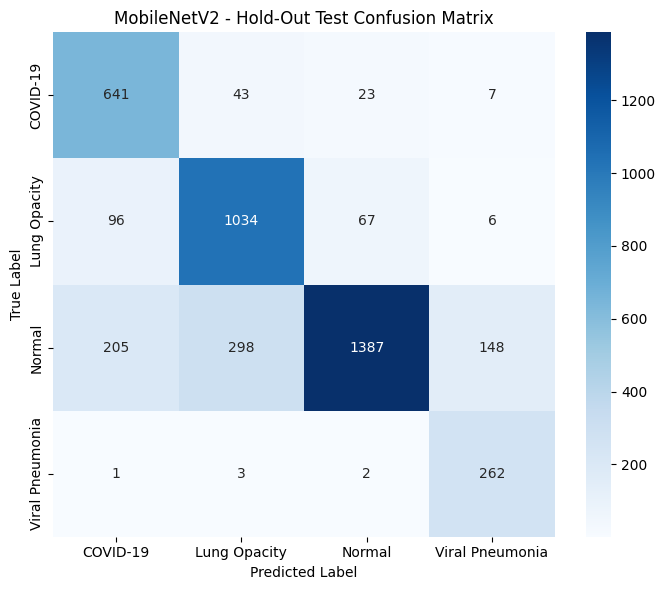

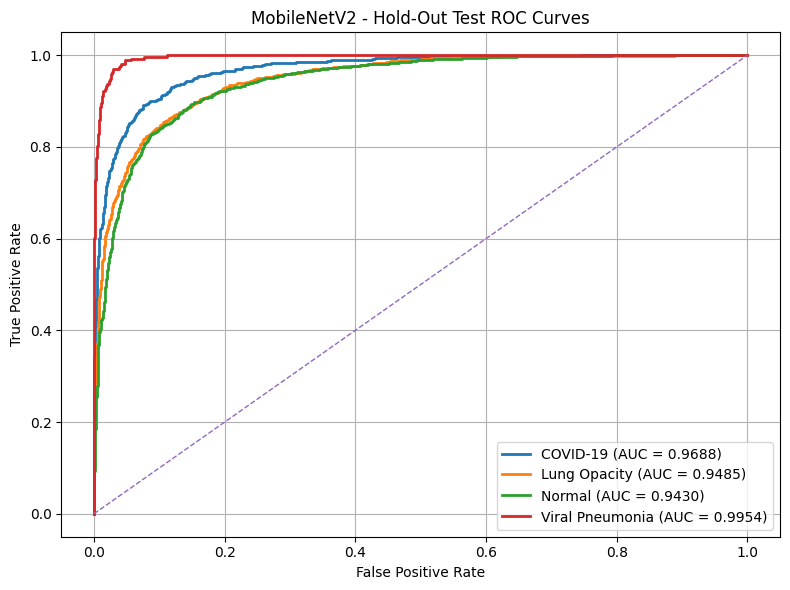

Class AUC scores:
COVID-19: 0.9688
Lung Opacity: 0.9485
Normal: 0.9430
Viral Pneumonia: 0.9954


In [23]:
plot_confusion_matrix(
    test_prediction_result["y_true"],
    test_prediction_result["y_pred"],
    title=f"{selected_model_name} - Hold-Out Test Confusion Matrix",
)

test_auc_scores = plot_roc_curves(
    test_prediction_result["y_true"],
    test_prediction_result["y_prob"],
    title=f"{selected_model_name} - Hold-Out Test ROC Curves",
)

print("Class AUC scores:")
for class_name, class_auc in test_auc_scores.items():
    print(f"{class_name}: {class_auc:.4f}")


## 18. Error Analysis

The Keras version showed Lung Opacity recall as the main weakness, with confusion between Lung Opacity and Normal. The next cell inspects the PyTorch confusion matrix in the same way.


In [24]:
confusion_df = pd.DataFrame(
    confusion_matrix(
        test_prediction_result["y_true"],
        test_prediction_result["y_pred"],
        labels=np.arange(NUM_CLASSES),
    ),
    index=[f"True {name}" for name in DISPLAY_CLASS_NAMES],
    columns=[f"Pred {name}" for name in DISPLAY_CLASS_NAMES],
)

display(confusion_df)

lung_opacity_index = CLASS_TO_INDEX["Lung_Opacity"]
normal_index = CLASS_TO_INDEX["Normal"]

lung_opacity_as_normal = confusion_df.iloc[lung_opacity_index, normal_index]
normal_as_lung_opacity = confusion_df.iloc[normal_index, lung_opacity_index]

print("Lung Opacity predicted as Normal:", lung_opacity_as_normal)
print("Normal predicted as Lung Opacity:", normal_as_lung_opacity)


,Pred COVID-19,Pred Lung Opacity,Pred Normal,Pred Viral Pneumonia
True COVID-19,641,43,23,7
True Lung Opacity,96,1034,67,6
True Normal,205,298,1387,148
True Viral Pneumonia,1,3,2,262


Lung Opacity predicted as Normal: 67
Normal predicted as Lung Opacity: 298


## 19. Grad-CAM Explainability

Grad-CAM highlights the image regions that most influenced a CNN-style model's prediction. It is used here as the main explainability method because it is faster and more stable for PyTorch image models than SHAP in this setting.


In [25]:
class GradCAM:
    """Minimal Grad-CAM implementation for PyTorch CNN-style models."""

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_index=None):
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(input_tensor)

        if class_index is None:
            class_index = int(logits.argmax(dim=1).item())

        score = logits[:, class_index].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def get_gradcam_target_layer(model, model_name):
    """Choose the last useful convolutional layer for Grad-CAM."""

    if model_name == "CNN":
        return model.features[12]

    if model_name == "MobileNetV2":
        return model.features[-1]

    raise ValueError(f"Unsupported model name: {model_name}")


def overlay_cam_on_image(image, cam, alpha=0.45):
    """Blend a heatmap with the original image."""

    heatmap = plt.cm.jet(cam)[..., :3]
    overlay = (1 - alpha) * image + alpha * heatmap
    return np.clip(overlay, 0, 1)


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


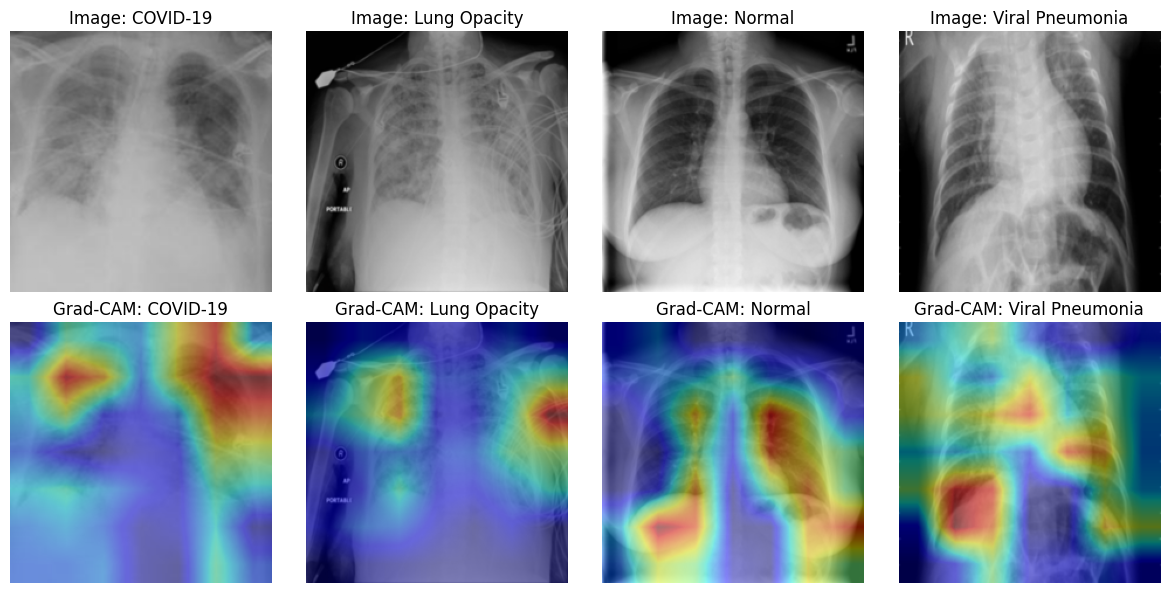

In [28]:
def select_one_correct_example_per_class(prediction_result):
    """Find one correctly classified test example per class for Grad-CAM."""

    selected = []
    y_true = prediction_result["y_true"]
    y_pred = prediction_result["y_pred"]
    paths = prediction_result["paths"]

    for class_index in range(NUM_CLASSES):
        matches = np.where((y_true == class_index) & (y_pred == class_index))[0]

        if len(matches) == 0:
            continue

        selected.append({
            "class_index": class_index,
            "path": paths[matches[0]],
        })

    return selected


class GradCAM:
    """Minimal Grad-CAM implementation for PyTorch CNN-style models."""

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None # Will store the output tensor of target_layer

        # Register a forward hook to save the activations.
        # Crucially, we do NOT detach here, and we call retain_grad().
        def save_activation_and_retain_grad_hook(module, inputs, output):
            self.activations = output
            if not output.requires_grad:
                # In case the output implicitly doesn't require grad (e.g., from frozen backbone)
                # This ensures the tensor itself can track gradients
                self.activations.requires_grad_(True)
            self.activations.retain_grad() # This makes sure .grad is populated after backward()

        self.forward_handle = target_layer.register_forward_hook(save_activation_and_retain_grad_hook)
        self.backward_handle = None # Explicitly set to None as it's not used in this approach.

    def __call__(self, input_tensor, class_index=None):
        self.model.eval()
        self.model.zero_grad()

        # Forward pass. The hook will populate self.activations.
        logits = self.model(input_tensor)

        if class_index is None:
            class_index = int(logits.argmax(dim=1).item())

        score = logits[:, class_index].sum()

        # Perform backward pass. This will populate self.activations.grad
        # because retain_grad() was called on self.activations.
        score.backward(retain_graph=True)

        # Check if activations and their gradients were successfully captured.
        if self.activations is None or self.activations.grad is None:
            raise RuntimeError(
                "Could not get activations or gradients from the target layer. "
                "Ensure gradients can flow to the target layer's output and `retain_grad()` was called."
            )

        # Gradients are now in self.activations.grad
        gradients = self.activations.grad.detach() # Gradients of the score w.r.t. activations

        # Perform global average pooling on the gradients
        weights = gradients.mean(dim=(2, 3), keepdim=True)

        # Create CAM: element-wise product of weights and activations, then sum
        # Detach self.activations here to prevent graph creation for CAM visualization itself.
        cam = (weights * self.activations.detach()).sum(dim=1)

        # Apply ReLU to CAM
        cam = F.relu(cam)

        # Interpolate CAM to original image size
        cam = F.interpolate(
            cam.unsqueeze(1),
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        # Normalize CAM
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        # No backward_handle to remove in this version.


def get_gradcam_target_layer(model, model_name):
    """Choose the last useful convolutional layer for Grad-CAM."""

    if model_name == "CNN":
        return model.features[12]

    if model_name == "MobileNetV2":
        return model.features[-1]

    raise ValueError(f"Unsupported model name: {model_name}")


def overlay_cam_on_image(image, cam, alpha=0.45):
    """Blend a heatmap with the original image."""

    heatmap = plt.cm.jet(cam)[..., :3]
    overlay = (1 - alpha) * image + alpha * heatmap
    return np.clip(overlay, 0, 1)


def show_gradcam_examples(model, model_name, selected_examples):
    """Display Grad-CAM overlays for selected test examples."""

    transform = get_transforms(model_name, train=False)
    target_layer = get_gradcam_target_layer(model, model_name)
    gradcam = GradCAM(model.to(DEVICE), target_layer)

    plt.figure(figsize=(12, 6))

    for plot_index, example in enumerate(selected_examples, start=1):
        image_path = example["path"]
        true_class_index = example["class_index"]

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        input_tensor = transform(image).unsqueeze(0).to(DEVICE)

        cam, logits = gradcam(input_tensor, class_index=true_class_index)
        predicted_class_index = int(logits.argmax(dim=1).item())

        display_image = denormalize_tensor(
            input_tensor.squeeze(0).detach().cpu(),
            model_name,
        )

        overlay = overlay_cam_on_image(display_image, cam)

        plt.subplot(2, NUM_CLASSES, plot_index)
        plt.imshow(display_image)
        plt.title(f"Image: {DISPLAY_CLASS_NAMES[true_class_index]}")
        plt.axis("off")

        plt.subplot(2, NUM_CLASSES, plot_index + NUM_CLASSES)
        plt.imshow(overlay)
        plt.title(f"Grad-CAM: {DISPLAY_CLASS_NAMES[predicted_class_index]}")
        plt.axis("off")

    gradcam.close()
    plt.tight_layout()
    plt.show()


gradcam_examples = select_one_correct_example_per_class(test_prediction_result)
show_gradcam_examples(final_model, selected_model_name, gradcam_examples)


## 20. Optional SHAP Note

SHAP is not run by default in this PyTorch notebook because it can be slow and less stable for large image models. Grad-CAM is the main explainability method for this project. If SHAP is required later, it should be tested on a very small balanced sample first.


In [29]:
RUN_OPTIONAL_SHAP = False

if RUN_OPTIONAL_SHAP:
    print(
        "Optional SHAP is intentionally disabled by default. "
        "Use Grad-CAM as the primary explanation method, and only add SHAP "
        "after testing runtime and stability on a small balanced sample."
    )
else:
    print("SHAP skipped. Grad-CAM is the main explainability method in this PyTorch version.")


SHAP skipped. Grad-CAM is the main explainability method in this PyTorch version.


## 21. Final Summary

This PyTorch notebook rebuilds the AI for Medicine chest X-ray classification project with a clean and reproducible structure:

- same 4-class COVID-19 Radiography Database
- image/mask quality checks
- corrupted-file screening
- exact duplicate removal before splitting
- stratified 80/20 development/test split
- untouched hold-out test set
- stratified 5-fold cross-validation on the development set
- exactly two models: custom CNN and pretrained MobileNetV2
- class-weighted loss for imbalance
- early stopping, checkpointing, and learning-rate scheduling
- final test classification report, confusion matrix, ROC curves, macro AUC, and Grad-CAM

The expected scientific interpretation should be compared against the previous Keras result. If the PyTorch MobileNetV2 result is close to the previous ~89.72% hold-out accuracy, the reimplementation is consistent. If it differs, likely causes include architecture differences, ImageNet preprocessing differences, optimizer behavior, augmentation, and training stochasticity.
